# Adult Census Income - Exploration et visualisation (EDA)
Objectif : comprendre les données **avant** de les modifier. Place `adult.data` et `adult.test` dans le même dossier que ce notebook.

## 0. Imports et chargement

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [10]:
# Les fichiers adult.data et adult.test doivent être dans le même dossier que le notebook
cols = ["age","workclass","fnlwgt","education","education-num","marital-status","occupation",
        "relationship","race","sex","capital-gain","capital-loss","hours-per-week","native-country","income"]
train = pd.read_csv("adult/adult.data", names=cols, skipinitialspace=True)
test  = pd.read_csv("adult/adult.test", names=cols, skipinitialspace=True, skiprows=1)  # 1ère ligne = commentaire
df = pd.concat([train, test], ignore_index=True)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 1. Caractéristiques principales du dataset

In [11]:
print("Dimensions :", df.shape)
df.info()

Dimensions : (48842, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [12]:
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(exclude="number").columns.tolist()
print("Numériques  :", num_cols)
print("Catégorielles :", cat_cols)
print("Doublons :", df.duplicated().sum())

Numériques  : ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Catégorielles : ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']
Doublons : 29


In [13]:
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


In [14]:
display(df.describe(exclude="number").T)


,count,unique,top,freq
workclass,48842,9,Private,33906
education,48842,16,HS-grad,15784
marital-status,48842,7,Married-civ-spouse,22379
occupation,48842,15,Prof-specialty,6172
relationship,48842,6,Husband,19716
race,48842,5,White,41762
sex,48842,2,Male,32650
native-country,48842,42,United-States,43832
income,48842,4,<=50K,24720


**Interprétation :** Le dataset (train + test) contient 48 842 lignes et 15 variables : 6 numériques (age, fnlwgt, education-num, capital-gain, capital-loss, hours-per-week) et 9 catégorielles (dont la cible income). On trouve 29 doublons. Les valeurs manquantes sont codées `?`, donc invisibles pour `isna()`.

## 2. Distributions des variables
### 2.1 Cible (income)

Modalités originales :
income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64

Modalités normalisées :
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Proportions :
income
<=50K    76.07
>50K     23.93
Name: proportion, dtype: float64


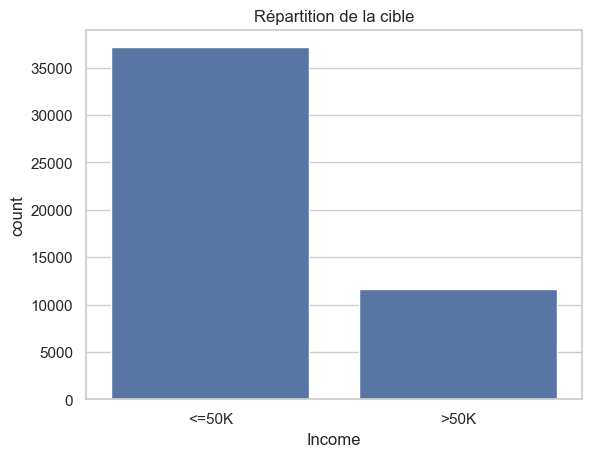

In [15]:
income_clean = (
    df["income"]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
)

print("Modalités originales :")
print(df["income"].value_counts())

print("\nModalités normalisées :")
print(income_clean.value_counts())

print("\nProportions :")
print((income_clean.value_counts(normalize=True) * 100).round(2))

sns.countplot(
    x=income_clean,
    order=["<=50K", ">50K"]
)
plt.title("Répartition de la cible")
plt.xlabel("Income")
plt.show()


**Interprétation :** Après normalisation, 76,1 % des personnes gagnent <=50K contre 23,9 % pour >50K. Les classes sont déséquilibrées : l'accuracy seule serait trompeuse (prédire toujours <=50K donne déjà 76 %), on utilisera F1, recall, AUC et class_weight ou SMOTE.

### 2.2 Variables numériques

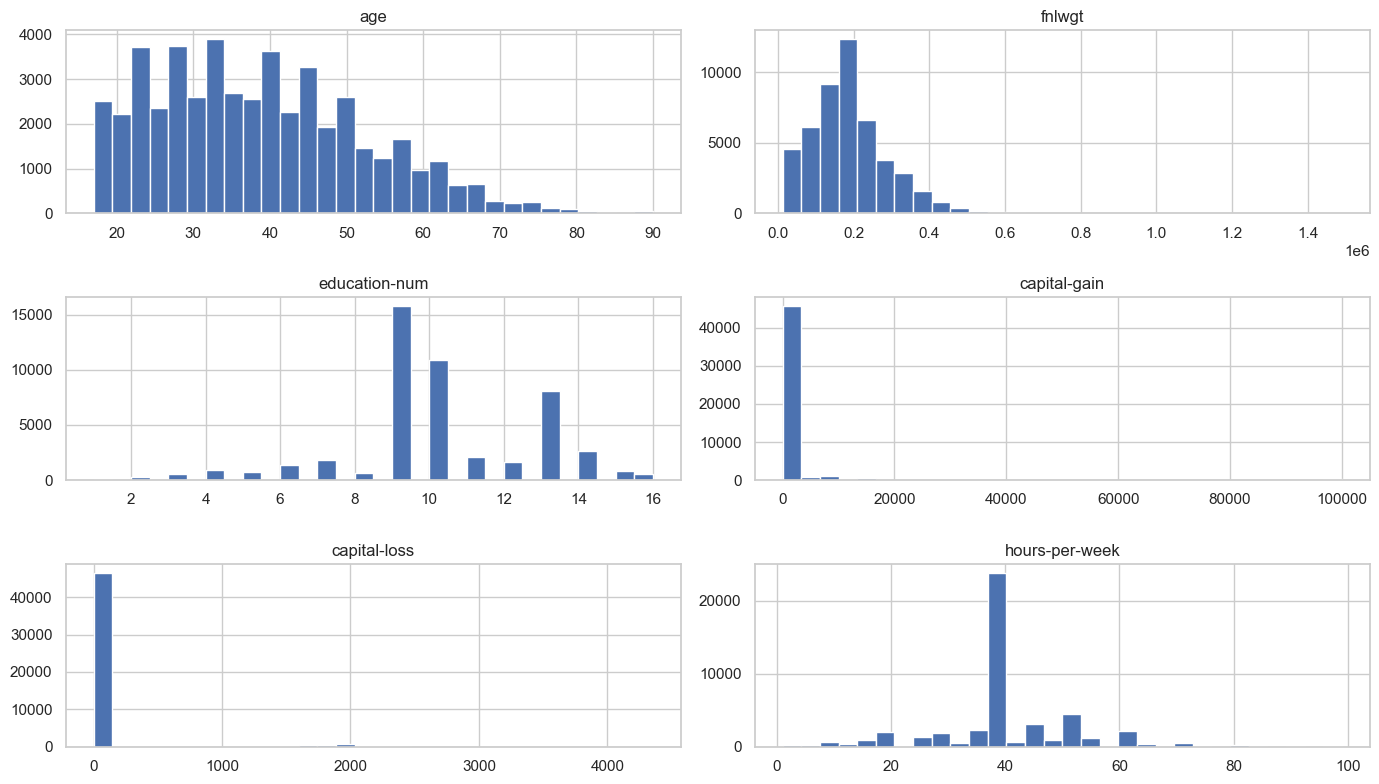

In [16]:
df[num_cols].hist(figsize=(14, 8), bins=30)
plt.tight_layout()
plt.show()

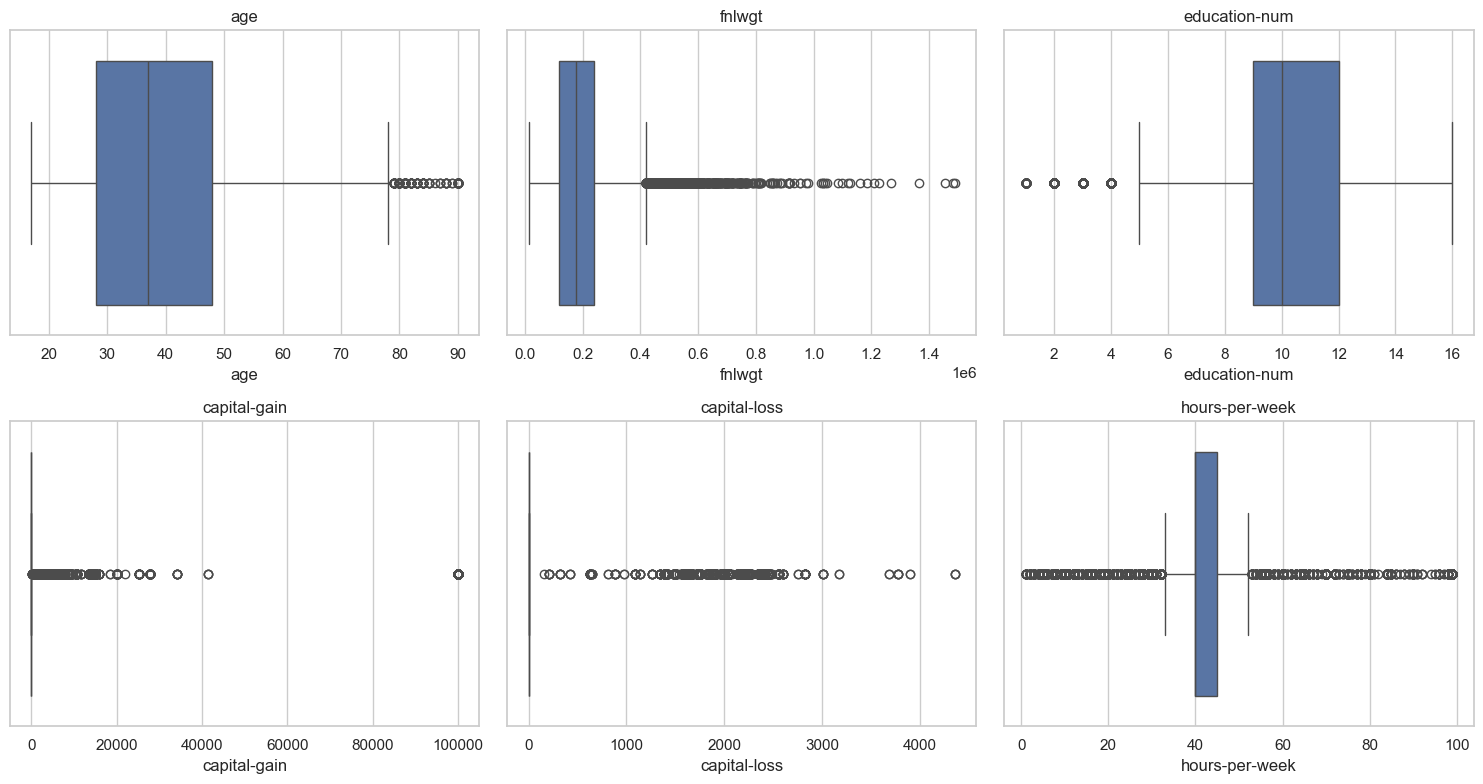

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


In [18]:
# Asymétrie et part de zéros
print(df[num_cols].skew().round(2))
print("\nPart de zéros :")
for c in ["capital-gain", "capital-loss"]:
    print(c, ":", round((df[c] == 0).mean() * 100, 1), "%")

age                0.56
fnlwgt             1.44
education-num     -0.32
capital-gain      11.89
capital-loss       4.57
hours-per-week     0.24
dtype: float64

Part de zéros :
capital-gain : 91.7 %
capital-loss : 95.3 %


**Interprétation :** capital-gain vaut 0 pour 91,7 % des personnes et capital-loss pour 95,3 %. Leur asymétrie est très forte (skew de 11,9 et 4,6) => transformation log1p ou variable binaire en préparation. age (0,56) et hours-per-week (0,24) sont peu asymétriques. fnlwgt (skew 1,44) est un poids d'échantillonnage, peu informatif.

### 2.3 Variables catégorielles

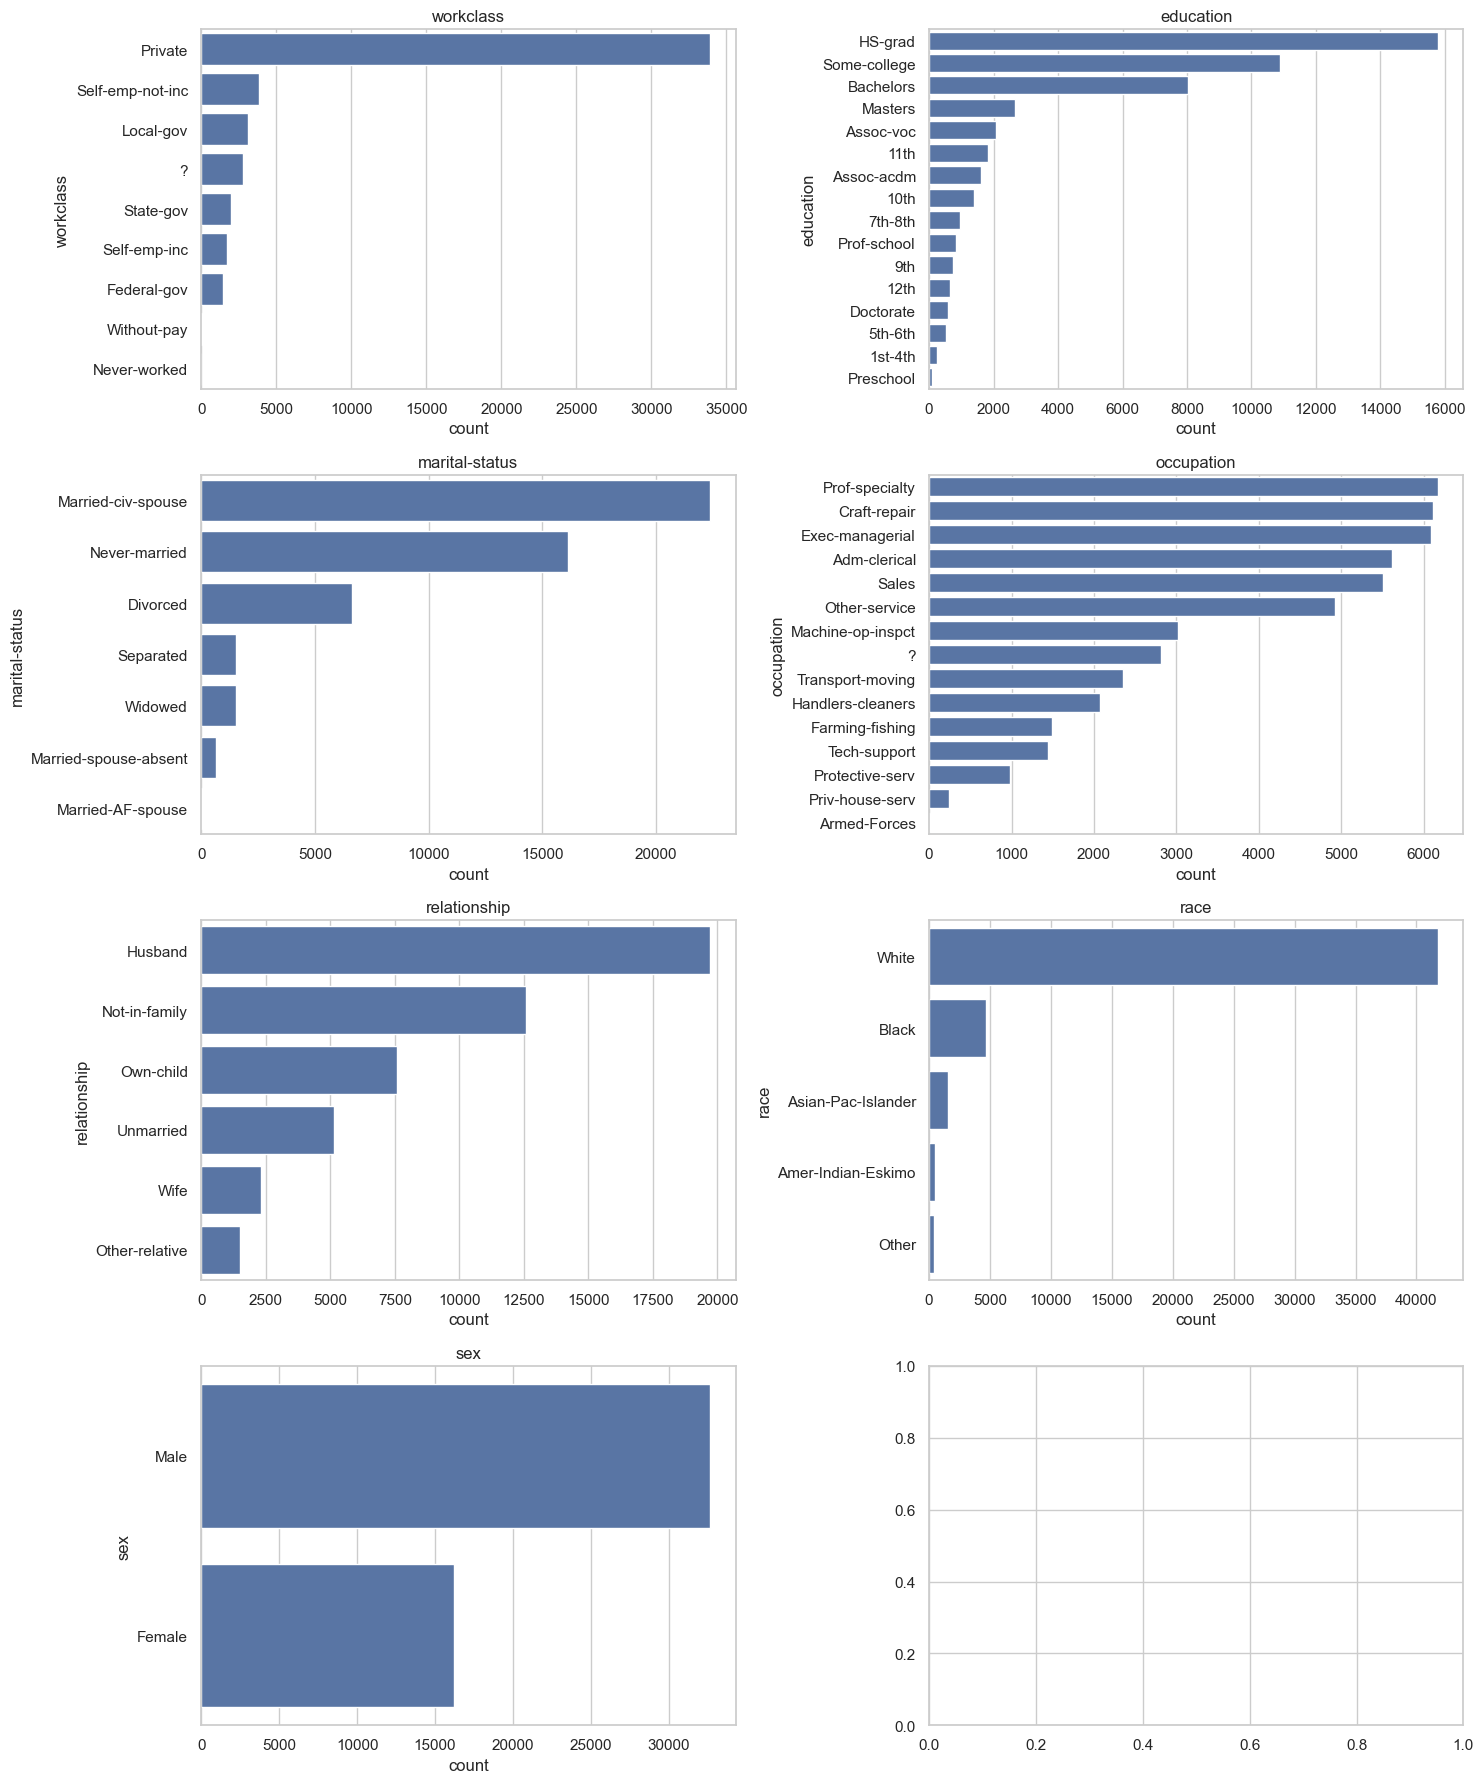

In [19]:
cat_plot = [
    c for c in cat_cols
    if c not in ["income", "native-country"]
]

fig, axes = plt.subplots(4, 2, figsize=(15, 18))

for ax, col in zip(axes.ravel(), cat_plot):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


In [20]:
# native-country : très déséquilibré
print(
    df["native-country"]
    .value_counts(normalize=True)
    .head(10)
    .round(4)
)


native-country
United-States    0.8974
Mexico           0.0195
?                0.0175
Philippines      0.0060
Germany          0.0042
Puerto-Rico      0.0038
Canada           0.0037
El-Salvador      0.0032
India            0.0031
Cuba             0.0028
Name: proportion, dtype: float64


**Interprétation :** native-country est dominé par United-States (89,7 %), les autres pays sont très minoritaires => regroupement US / Autre pour éviter des dizaines de colonnes One-Hot quasi vides. Le secteur Private domine aussi workclass.

## 3. Relations entre variables
### 3.1 Corrélations

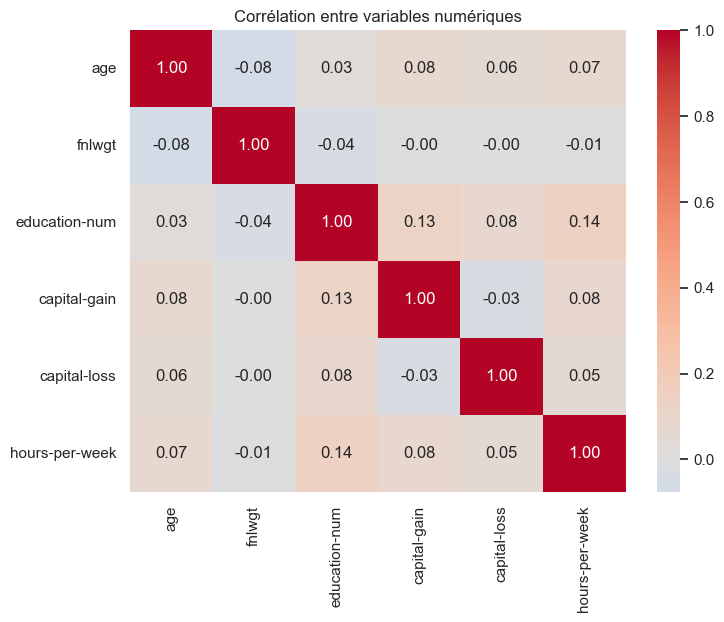

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Corrélation entre variables numériques")
plt.show()


**Interprétation :** Les corrélations entre numériques sont faibles (aucune forte hors diagonale), donc pas de multicolinéarité gênante. La plus notable : education-num et hours-per-week (0,14). fnlwgt n'est corrélée à rien.

### 3.2 Variables numériques vs revenu

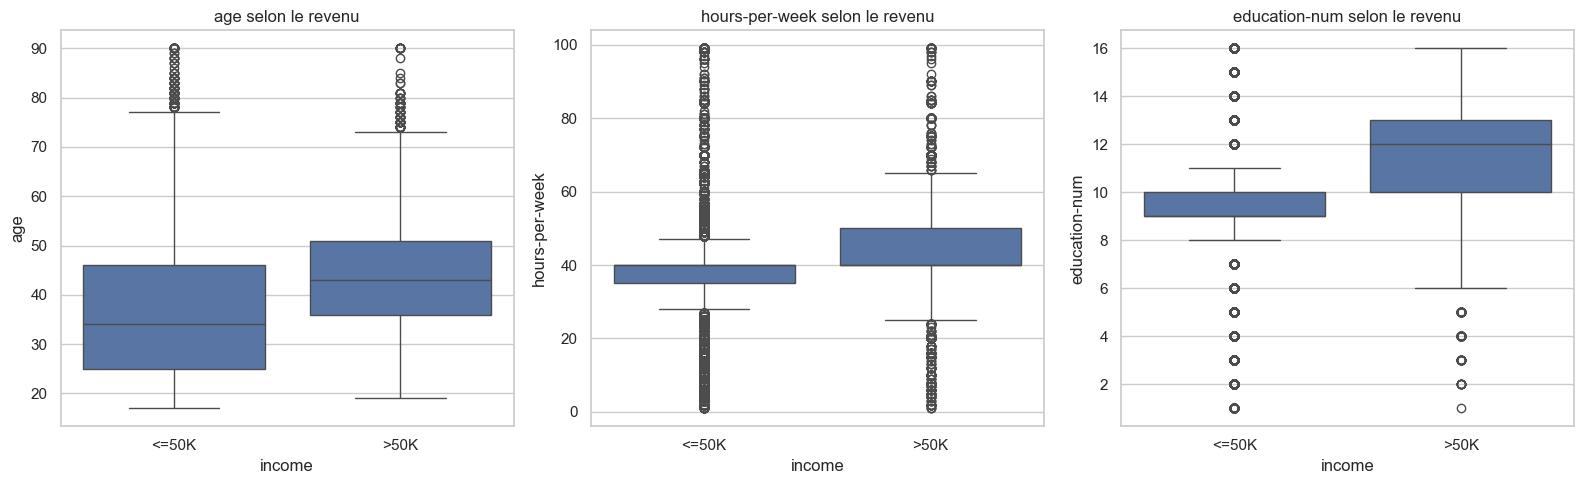

In [22]:
d = df.copy()
d["income"] = income_clean
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, c in zip(axes, ["age", "hours-per-week", "education-num"]):
    sns.boxplot(data=d, x="income", y=c, order=["<=50K", ">50K"], ax=ax)
    ax.set_title(f"{c} selon le revenu")
plt.tight_layout()
plt.show()

**Interprétation :** Les >50K sont en moyenne plus âgés (44,3 ans contre 36,9), travaillent plus (45,5 h contre 38,8 h) et sont plus diplômés (education-num 11,6 contre 9,6). Ces trois variables sont donc discriminantes pour la classification.

### 3.3 Variables catégorielles vs revenu

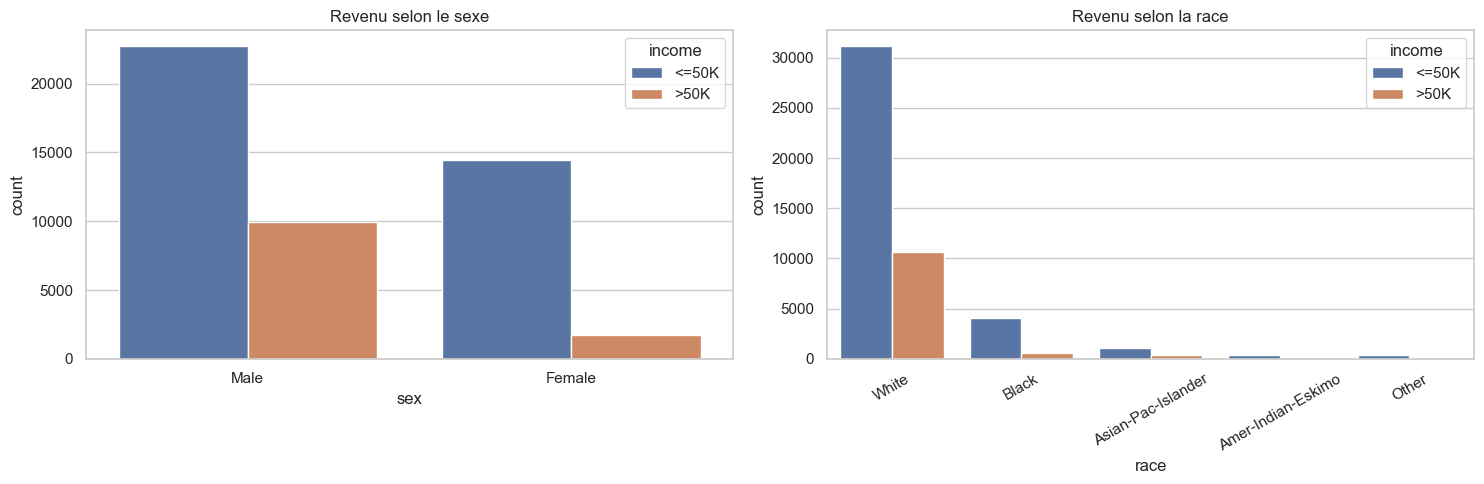

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=d, x="sex", hue="income", hue_order=["<=50K", ">50K"], ax=axes[0])
axes[0].set_title("Revenu selon le sexe")
sns.countplot(data=d, x="race", hue="income", hue_order=["<=50K", ">50K"], ax=axes[1])
axes[1].set_title("Revenu selon la race")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

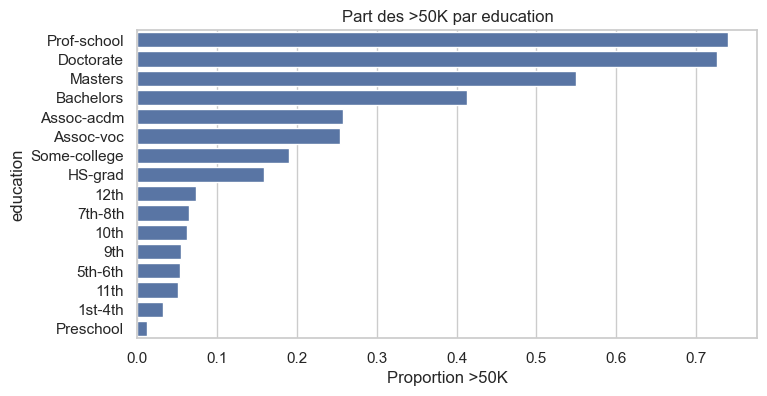

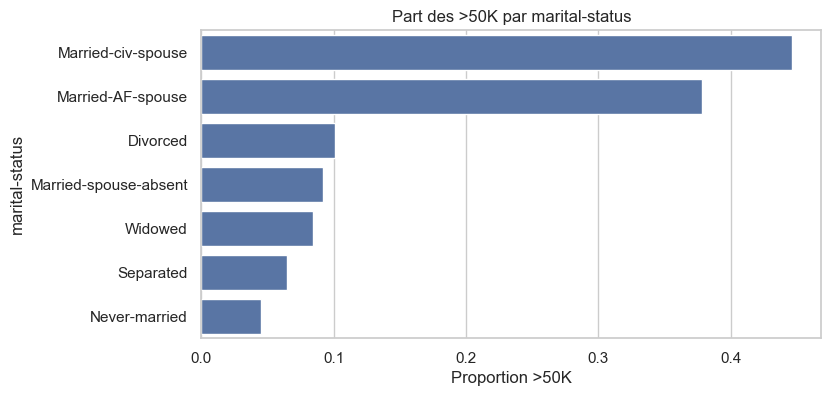

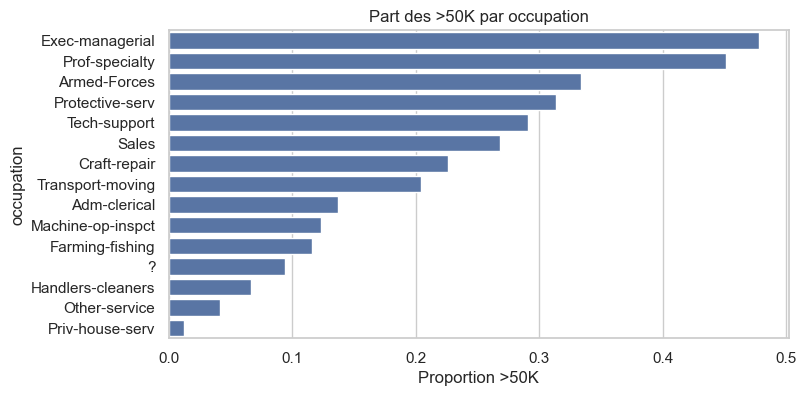

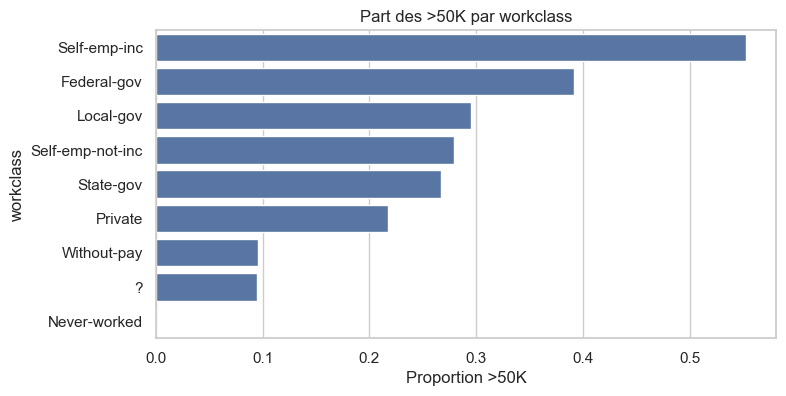

In [24]:
# Taux de revenu >50K par modalité
for c in ["education", "marital-status", "occupation", "workclass"]:
    rate = (d.assign(high=(d["income"] == ">50K")).groupby(c)["high"].mean()
              .sort_values(ascending=False))
    plt.figure(figsize=(8, 4))
    sns.barplot(x=rate.values, y=rate.index)
    plt.title(f"Part des >50K par {c}")
    plt.xlabel("Proportion >50K")
    plt.show()

**Interprétation :** 30,4 % des hommes gagnent >50K contre 10,9 % des femmes. Les personnes mariées (Married-civ-spouse : 44,6 %) sont bien au-dessus des autres statuts (6 à 10 %). Le taux monte avec le diplôme : Prof-school 74 %, Doctorate 73 %, Masters 55 %, Bachelors 41 %. Les Self-emp-inc (55 %) et Federal-gov (39 %) dominent côté workclass. Attention : sexe et statut marital sont liés (biais possible à discuter).

## 4. Détection des anomalies
### 4.1 Valeurs manquantes

In [25]:
# Les manquants peuvent être NaN ou "?" selon la méthode de chargement
missing = df.isna().sum() + (df.astype(str).apply(lambda s: s.str.strip() == "?")).sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print((missing / len(df) * 100).round(2).astype(str) + " %")

occupation        2809
workclass         2799
native-country     857
dtype: int64
occupation        5.75 %
workclass         5.73 %
native-country    1.75 %
dtype: object


**Interprétation :** 2 799 manquants dans workclass (5,7 %), 2 809 dans occupation (5,8 %) et 857 dans native-country (1,8 %). Ce sont des variables catégorielles avec peu de manquants, souvent sur les mêmes lignes => imputation par le mode ou catégorie Unknown en préparation.

### 4.2 Outliers

In [26]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    i = q3 - q1
    return ((s < q1 - 1.5 * i) | (s > q3 + 1.5 * i)).sum()

for c in num_cols:
    print(f"{c:15s} outliers IQR : {iqr_outliers(df[c])}")

print("\ncapital-gain = 99999 :", (df["capital-gain"] == 99999).sum())
print("hours-per-week > 80  :", (df["hours-per-week"] > 80).sum())
print("hours-per-week < 10  :", (df["hours-per-week"] < 10).sum())
print("age > 85             :", (df["age"] > 85).sum())

age             outliers IQR : 216
fnlwgt          outliers IQR : 1453
education-num   outliers IQR : 1794
capital-gain    outliers IQR : 4035
capital-loss    outliers IQR : 2282
hours-per-week  outliers IQR : 13496

capital-gain = 99999 : 244
hours-per-week > 80  : 318
hours-per-week < 10  : 700
age > 85             : 67


**Interprétation :** 244 personnes ont capital-gain = 99999 : c'est un code de plafonnement (valeur tronquée), à ne pas supprimer aveuglément mais à traiter avec log ou winsorisation. On compte aussi 318 personnes à plus de 80 h/semaine, 700 à moins de 10 h et 67 de plus de 85 ans : rares mais plausibles, donc winsorisation plutôt que suppression.

### 4.3 Doublons et incohérences

In [27]:
print("Doublons :", df.duplicated().sum())
print("\nModalités de la cible :", df["income"].unique())

# education et education-num sont-elles redondantes ?
print(df.groupby("education")["education-num"].nunique().max(), "(1 = redondance parfaite)")

Doublons : 29

Modalités de la cible : ['<=50K' '>50K' '<=50K.' '>50K.']
1 (1 = redondance parfaite)


## 5. Synthèse des anomalies (base de la partie Nettoyage)
| Anomalie | Où | Action prévue |
|---|---|---|
| Valeurs manquantes | workclass, occupation, native-country | Imputation (mode / Unknown) |
| Cible avec un point | income | Normaliser puis encoder 0/1 |
| Outliers / code 99999 | capital-gain, hours-per-week | IQR ou winsorisation, log |
| Asymétrie | capital-gain, capital-loss | log1p |
| Redondance | education / education-num | Supprimer education |
| Doublons | 29 lignes | Supprimer |
| Déséquilibre de la cible | income | class_weight / SMOTE, métriques F1/AUC |

In [28]:
df_clean = df.copy()

# 1. Normaliser la cible
df_clean["income"] = (
    df_clean["income"]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
)

# 2. Encoder la cible
df_clean["income"] = df_clean["income"].map({
    "<=50K": 0,
    ">50K": 1
})

# 3. Supprimer les variables redondantes / non retenues
df_clean = df_clean.drop(
    columns=["education", "fnlwgt"],
    errors="ignore"
)

print("Shape après suppression des variables redondantes :", df_clean.shape)


Shape après suppression des variables redondantes : (48842, 13)


In [29]:
# ============================================================
# 3.2 - DETECTION DES VALEURS MANQUANTES
# ============================================================

missing = df_clean.isnull().sum()

print("Valeurs manquantes par variable :")
print(missing)

print("\nPourcentage de valeurs manquantes :")

missing_percent = (
    df_clean.isnull().sum() / len(df_clean) * 100
)

print(missing_percent[missing_percent > 0])

Valeurs manquantes par variable :
age               0
workclass         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

Pourcentage de valeurs manquantes :
Series([], dtype: float64)


In [30]:
duplicates_before = df_clean.duplicated().sum()

print("Doublons avant suppression :", duplicates_before)
print(
    "Pourcentage :",
    round(duplicates_before / len(df_clean) * 100, 2),
    "%"
)

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Lignes après suppression :", len(df_clean))
print("Doublons après :", df_clean.duplicated().sum())


Doublons avant suppression : 6374
Pourcentage : 13.05 %
Lignes après suppression : 42468
Doublons après : 0


In [31]:
# ============================================================
# 3. DATA PREPARATION
# ============================================================

# 3.1 Copie du dataset original
df_clean = df.copy()

print("Shape initiale :", df_clean.shape)

# ============================================================
# 3.2 DETECTION DES VALEURS MANQUANTES
# ============================================================

missing = df_clean.isnull().sum()

print("\nValeurs manquantes :")
print(missing)

print("\nPourcentage de valeurs manquantes :")

missing_percent = (
    df_clean.isnull().sum() / len(df_clean) * 100
)

print(
    missing_percent[missing_percent > 0]
)

Shape initiale : (48842, 15)

Valeurs manquantes :
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

Pourcentage de valeurs manquantes :
Series([], dtype: float64)


In [32]:
# Vérification finale des valeurs manquantes

missing = df_clean.isnull().sum()

print("Valeurs manquantes par variable :")
print(missing)

print("\nNombre total de valeurs manquantes :",
      missing.sum())

Valeurs manquantes par variable :
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

Nombre total de valeurs manquantes : 0


In [33]:
print("Nombre de doublons :", df_clean.duplicated().sum())

Nombre de doublons : 29


In [34]:
# ============================================================
# ANALYSE DES DOUBLONS
# ============================================================

print("Nombre total de lignes :", len(df_clean))
print("Nombre de doublons :", df_clean.duplicated().sum())

print("Pourcentage de doublons :",
      round(df_clean.duplicated().sum() / len(df_clean) * 100, 2),
      "%")

Nombre total de lignes : 48842
Nombre de doublons : 29
Pourcentage de doublons : 0.06 %


In [35]:
# Afficher quelques doublons
duplicates = df_clean[df_clean.duplicated(keep=False)]

print(duplicates.head(10))

      age workclass  fnlwgt     education  education-num      marital-status  \
2303   90   Private   52386  Some-college             10       Never-married   
3917   19   Private  251579  Some-college             10       Never-married   
4325   25   Private  308144     Bachelors             13       Never-married   
4767   21   Private  250051  Some-college             10       Never-married   
4881   25   Private  308144     Bachelors             13       Never-married   
4940   38   Private  207202       HS-grad              9  Married-civ-spouse   
5104   90   Private   52386  Some-college             10       Never-married   
5579   27   Private  255582       HS-grad              9       Never-married   
5805   20   Private  107658  Some-college             10       Never-married   
5842   25   Private  195994       1st-4th              2       Never-married   

             occupation   relationship                race     sex  \
2303      Other-service  Not-in-family  Asian-Pac

In [36]:
# Vérification des doublons exacts
print("Doublons exacts :", df_clean.duplicated().sum())

# Vérifier les doublons en ignorant la première occurrence
print("Doublons à supprimer :", df_clean.duplicated(keep='first').sum())

Doublons exacts : 29
Doublons à supprimer : 29


In [37]:
# Suppression des doublons exacts
df_clean = df_clean.drop_duplicates()

print("Nombre de lignes après suppression :", len(df_clean))
print("Nombre de doublons après :", df_clean.duplicated().sum())

Nombre de lignes après suppression : 48813
Nombre de doublons après : 0


In [38]:
# Capital net : information synthétique sur le résultat du capital
df_clean["capital_net"] = (
    df_clean["capital-gain"]
    - df_clean["capital-loss"]
)

# Indicateur binaire du statut marital
df_clean["is_married"] = (
    df_clean["marital-status"]
    .isin(["Married-civ-spouse", "Married-AF-spouse"])
    .astype(int)
)

# Regroupement de l'âge en tranches
df_clean["age_bucket"] = pd.cut(
    df_clean["age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=["<25", "25-35", "35-45", "45-55", "55-65", "65+"],
    include_lowest=True
)

print("Nouvelles features :")
print(["capital_net", "is_married", "age_bucket"])

print("\nRépartition de is_married :")
print(df_clean["is_married"].value_counts())

print("\nRépartition de age_bucket :")
print(df_clean["age_bucket"].value_counts().sort_index())


Nouvelles features :
['capital_net', 'is_married', 'age_bucket']

Répartition de is_married :
is_married
0    26404
1    22409
Name: count, dtype: int64

Répartition de age_bucket :
age_bucket
<25       9614
25-35    12713
35-45    11947
45-55     8292
55-65     4445
65+       1802
Name: count, dtype: int64


In [39]:
# ============================================================
# WINSORISATION DE HOURS-PER-WEEK
# ============================================================

lower = df_clean['hours-per-week'].quantile(0.01)
upper = df_clean['hours-per-week'].quantile(0.99)

print("Limite basse :", lower)
print("Limite haute :", upper)

df_clean['hours-per-week'] = df_clean[
    'hours-per-week'
].clip(
    lower=lower,
    upper=upper
)

print("\nAprès winsorisation :")
print(df_clean['hours-per-week'].describe())

Limite basse : 8.0
Limite haute : 80.0

Après winsorisation :
count    48813.000000
mean        40.376252
std         11.971635
min          8.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         80.000000
Name: hours-per-week, dtype: float64


In [40]:
df_clean = df_clean.drop(
    columns=['education', 'fnlwgt'],
    errors='ignore'
)

In [41]:
# ============================================================
# VARIABLES CATEGORIELLES
# ============================================================

cat_features = [
    'workclass',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country',
    'age_bucket'
]

print("Variables catégorielles :")
print(cat_features)

Variables catégorielles :
['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'age_bucket']


In [42]:
# ============================================================
# 3.6 VARIABLES CATEGORIELLES
# ============================================================

for col in cat_features:
    print("\n", col)
    print(df_clean[col].value_counts(dropna=False))


 workclass
workclass
Private             33879
Self-emp-not-inc     3861
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

 marital-status
marital-status
Married-civ-spouse       22372
Never-married            16098
Divorced                  6630
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

 occupation
occupation
Prof-specialty       6167
Craft-repair         6107
Exec-managerial      6084
Adm-clerical         5608
Sales                5504
Other-service        4919
Machine-op-inspct    3019
?                    2809
Transport-moving     2355
Handlers-cleaners    2071
Farming-fishing      1487
Tech-support         1445
Protective-serv       983
Priv-house-serv       240
Armed-Forces           15
Name: count, dtype: int64

 r

In [43]:
for col in cat_features:
    print(f"\n--- {col} ---")
    freq = df_clean[col].value_counts(normalize=True) * 100
    print(freq.round(2))


--- workclass ---
workclass
Private             69.41
Self-emp-not-inc     7.91
Local-gov            6.42
?                    5.73
State-gov            4.06
Self-emp-inc         3.47
Federal-gov          2.93
Without-pay          0.04
Never-worked         0.02
Name: proportion, dtype: float64

--- marital-status ---
marital-status
Married-civ-spouse       45.83
Never-married            32.98
Divorced                 13.58
Separated                 3.13
Widowed                   3.11
Married-spouse-absent     1.29
Married-AF-spouse         0.08
Name: proportion, dtype: float64

--- occupation ---
occupation
Prof-specialty       12.63
Craft-repair         12.51
Exec-managerial      12.46
Adm-clerical         11.49
Sales                11.28
Other-service        10.08
Machine-op-inspct     6.18
?                     5.75
Transport-moving      4.82
Handlers-cleaners     4.24
Farming-fishing       3.05
Tech-support          2.96
Protective-serv       2.01
Priv-house-serv       0.49
Armed-

In [44]:
OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [45]:
num_features = [
    'age',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week',
    'capital_net'
]

print("Variables numériques :")
print(num_features)

print("\nTypes :")
print(df_clean[num_features].dtypes)

Variables numériques :
['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'capital_net']

Types :
age               int64
education-num     int64
capital-gain      int64
capital-loss      int64
hours-per-week    int64
capital_net       int64
dtype: object


In [46]:
df_clean[num_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,48813.0,38.647348,13.709005,17.0,28.0,37.0,48.0,90.0
education-num,48813.0,10.078688,2.570257,1.0,9.0,10.0,12.0,16.0
capital-gain,48813.0,1079.708705,7454.185982,0.0,0.0,0.0,0.0,99999.0
capital-loss,48813.0,87.554299,403.118605,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48813.0,40.376252,11.971635,8.0,40.0,40.0,45.0,80.0
capital_net,48813.0,992.154406,7477.731168,-4356.0,0.0,0.0,0.0,99999.0


In [47]:
print("Skewness des variables numériques :")
print(df_clean[num_features].skew().sort_values(ascending=False))

Skewness des variables numériques :
capital-gain      11.891093
capital_net       11.811381
capital-loss       4.568263
age                0.556775
hours-per-week     0.017305
education-num     -0.315007
dtype: float64


In [48]:
print(df_clean[['capital-gain', 'capital-loss', 'capital_net']].head(10))

   capital-gain  capital-loss  capital_net
0          2174             0         2174
1             0             0            0
2             0             0            0
3             0             0            0
4             0             0            0
5             0             0            0
6             0             0            0
7             0             0            0
8         14084             0        14084
9          5178             0         5178


In [49]:
print("Capital-gain unique :", df_clean['capital-gain'].nunique())
print("Capital-loss unique :", df_clean['capital-loss'].nunique())
print("Capital-net unique :", df_clean['capital_net'].nunique())

Capital-gain unique : 123
Capital-loss unique : 99
Capital-net unique : 221


In [50]:
for col in num_features:
    print(f"\n--- {col} ---")
    print("Min :", df_clean[col].min())
    print("Max :", df_clean[col].max())
    print("Q1  :", df_clean[col].quantile(0.25))
    print("Q3  :", df_clean[col].quantile(0.75))


--- age ---
Min : 17
Max : 90
Q1  : 28.0
Q3  : 48.0

--- education-num ---
Min : 1
Max : 16
Q1  : 9.0
Q3  : 12.0

--- capital-gain ---
Min : 0
Max : 99999
Q1  : 0.0
Q3  : 0.0

--- capital-loss ---
Min : 0
Max : 4356
Q1  : 0.0
Q3  : 0.0

--- hours-per-week ---
Min : 8
Max : 80
Q1  : 40.0
Q3  : 45.0

--- capital_net ---
Min : -4356
Max : 99999
Q1  : 0.0
Q3  : 0.0


In [51]:
print("hours-per-week > 80 :", (df_clean['hours-per-week'] > 80).sum())
print("hours-per-week < 10 :", (df_clean['hours-per-week'] < 10).sum())

print("\nage > 85 :", (df_clean['age'] > 85).sum())

hours-per-week > 80 : 0
hours-per-week < 10 : 700

age > 85 : 66


In [52]:
print(df_clean[['hours-per-week', 'age']].describe())

       hours-per-week           age
count    48813.000000  48813.000000
mean        40.376252     38.647348
std         11.971635     13.709005
min          8.000000     17.000000
25%         40.000000     28.000000
50%         40.000000     37.000000
75%         45.000000     48.000000
max         80.000000     90.000000


In [53]:
print("Valeurs hours-per-week les plus fréquentes :")
print(df_clean['hours-per-week'].value_counts().sort_index().tail(15))

Valeurs hours-per-week les plus fréquentes :
hours-per-week
65    355
66     23
67      6
68     16
69      1
70    437
72    107
73      4
74      3
75    105
76      4
77      9
78     13
79      1
80    528
Name: count, dtype: int64


In [54]:
print("Colonnes de feature engineering :")
print(['capital_net', 'is_married', 'age_bucket'])

print("\n--- capital_net ---")
print(df_clean['capital_net'].describe())

print("\n--- is_married ---")
print(df_clean['is_married'].value_counts())
print(df_clean['is_married'].value_counts(normalize=True) * 100)

print("\n--- age_bucket ---")
print(df_clean['age_bucket'].value_counts().sort_index())
print(df_clean['age_bucket'].value_counts(normalize=True).sort_index() * 100)

Colonnes de feature engineering :
['capital_net', 'is_married', 'age_bucket']

--- capital_net ---
count    48813.000000
mean       992.154406
std       7477.731168
min      -4356.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital_net, dtype: float64

--- is_married ---
is_married
0    26404
1    22409
Name: count, dtype: int64
is_married
0    54.092148
1    45.907852
Name: proportion, dtype: float64

--- age_bucket ---
age_bucket
<25       9614
25-35    12713
35-45    11947
45-55     8292
55-65     4445
65+       1802
Name: count, dtype: int64
age_bucket
<25      19.695573
25-35    26.044291
35-45    24.475037
45-55    16.987278
55-65     9.106181
65+       3.691640
Name: proportion, dtype: float64


In [55]:
print("=" * 60)
print("VÉRIFICATION FINALE DU DATASET")
print("=" * 60)

print("\n1. Dimensions :")
print(df_clean.shape)

print("\n2. Valeurs manquantes :")
print(df_clean.isnull().sum().sum())

print("\n3. Doublons :")
print(df_clean.duplicated().sum())

print("\n4. Types de données :")
print(df_clean.dtypes)

print("\n5. Distribution de la cible :")
print(df_clean['income'].value_counts())

print("\n6. Distribution de la cible (%) :")
print((df_clean['income'].value_counts(normalize=True) * 100).round(2))

VÉRIFICATION FINALE DU DATASET

1. Dimensions :
(48813, 16)

2. Valeurs manquantes :
0

3. Doublons :
4475

4. Types de données :
age                  int64
workclass           object
education-num        int64
marital-status      object
occupation          object
relationship        object
race                object
sex                 object
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country      object
income              object
capital_net          int64
is_married           int32
age_bucket        category
dtype: object

5. Distribution de la cible :
income
<=50K     24698
<=50K.    12430
>50K       7839
>50K.      3846
Name: count, dtype: int64

6. Distribution de la cible (%) :
income
<=50K     50.60
<=50K.    25.46
>50K      16.06
>50K.      7.88
Name: proportion, dtype: float64


In [56]:
X = df_clean.drop(columns=['income'])
y = df_clean['income']

print("Shape de X :", X.shape)
print("Shape de y :", y.shape)

print("\nColonnes utilisées pour X :")
print(X.columns.tolist())

print("\nDistribution de y :")
print(y.value_counts())

Shape de X : (48813, 15)
Shape de y : (48813,)

Colonnes utilisées pour X :
['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'capital_net', 'is_married', 'age_bucket']

Distribution de y :
income
<=50K     24698
<=50K.    12430
>50K       7839
>50K.      3846
Name: count, dtype: int64


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

print("\nDistribution de y_train (%) :")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nDistribution de y_test (%) :")
print((y_test.value_counts(normalize=True) * 100).round(2))

X_train : (39050, 15)
X_test  : (9763, 15)
y_train : (39050,)
y_test  : (9763,)

Distribution de y_train (%) :
income
<=50K     50.60
<=50K.    25.46
>50K      16.06
>50K.      7.88
Name: proportion, dtype: float64

Distribution de y_test (%) :
income
<=50K     50.60
<=50K.    25.46
>50K      16.06
>50K.      7.88
Name: proportion, dtype: float64


In [58]:
num_features = [
    'age',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week',
    'capital_net'
]
cat_features = [
    'workclass',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country',
    'age_bucket'
]

In [59]:


num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

print("Pipeline numérique créée :")
print(num_pipeline)

Pipeline numérique créée :
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


In [65]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# =========================
# Variables numériques
# =========================

num_features = [
    'age',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week',
    'capital_net'
]

# =========================
# Variables catégorielles
# =========================

cat_features = [
    'workclass',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country',
    'age_bucket'
]

# =========================
# Pipeline numérique
# =========================

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# =========================
# Pipeline catégoriel
# =========================

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

# =========================
# Preprocessor
# =========================

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

print("Preprocessor créé avec succès !")
print(preprocessor)

Preprocessor créé avec succès !
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'education-num', 'capital-gain',
                                  'capital-loss', 'hours-per-week',
                                  'capital_net']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['workclass', 'marital-status', 'occupation'

In [66]:
# Vérification des colonnes
print("Variables numériques :", num_features)
print("Variables catégorielles :", cat_features)

print("\nNombre de variables numériques :", len(num_features))
print("Nombre de variables catégorielles :", len(cat_features))

# Vérifier que toutes les colonnes existent
all_features = num_features + cat_features

missing_features = [
    col for col in all_features
    if col not in X_train.columns
]

print("\nColonnes manquantes :", missing_features)

Variables numériques : ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'capital_net']
Variables catégorielles : ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'age_bucket']

Nombre de variables numériques : 6
Nombre de variables catégorielles : 8

Colonnes manquantes : []
